In [4]:
#setup notebook
%load_ext autoreload
%autoreload 2
%matplotlib inline
import logging
logging.basicConfig(format='%(asctime)s %(levelname)s:%(message)s', level=logging.INFO, datefmt='%I:%M:%S')
from sdata.base import Base
from sdata.sclass import ProcessData

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


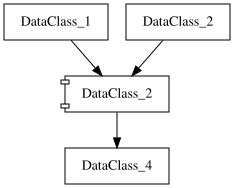

In [16]:
from typing import Dict, Type, List, Union, Optional, Any
import graphviz
from IPython.display import display, SVG

# Assuming Base, ProcessData, SUUID, Metadata, etc., are defined.

class ProcessNode(Base):
    """
    Unified base class for process nodes, supporting both leaf and composite processes.
    Leaf processes have empty processes list and override execute.
    Composite processes have processes list and use chaining in execute.
    """
    input_classes: Dict[str, Type[ProcessData]] = {}
    output_classes: Dict[str, Type[ProcessData]] = {}
    processes: List[Type['ProcessNode']] = []  # Class var for subprocess classes
    computation: str = ""  # Optional for display

    required_inputs: List[Type[ProcessData]] = []
    required_outputs: List[Type[ProcessData]] = []

    PROCESS_DATATYPE = 'ProcessNode'

    def __init__(self, name: str = "ProcessNode", inputs: Dict[str, ProcessData] = None, **kwargs: Any):
        super().__init__(name=name, **kwargs)
        self.metadata.add(
            self.SDATA_BFO_CLASS, "sdata.sclass:Prozess", dtype="str",
            description="sdata bfo class name", required=True
        )
        self.inputs: Dict[str, ProcessData] = inputs or {}
        self.outputs: Dict[str, ProcessData] = {}
        self.process_classes = self.__class__.processes  # Instance access to class var

    def validate_inputs(self) -> bool:
        """
        Prüft, ob alle erforderlichen Inputs vorhanden und vollständig sind.
        """
        for req_input in self.__class__.required_inputs:
            found = False
            for inp_key, inp in self.inputs.items():
                if isinstance(inp, req_input):
                    if not inp.is_complete():
                        raise ValueError(f"Input '{inp_key}' ({inp.name}) ist nicht vollständig.")
                    found = True
                    break
            if not found:
                raise ValueError(f"Fehlender erforderlicher Input: {req_input.__name__}")
        return True

    def execute(self) -> Dict[str, ProcessData]:
        if not self.validate_inputs():
            raise ValueError("Inputs not valid")
        
        if self.process_classes:  # Composite behavior
            intermediate = self.inputs.copy()
            for proc_type in self.process_classes:
                proc = proc_type(inputs={k: intermediate[k] for k in proc_type.input_classes if k in intermediate})
                proc_output = proc.execute()
                intermediate.update(proc_output)
            self.outputs = {k: intermediate[k] for k in self.__class__.output_classes}
            return self.outputs
        else:  # Leaf behavior
            raise NotImplementedError("Subclasses must implement execute for leaf processes.")

# Factory for leaf processes
def create_process_class(
    process_name: str,
    input_classes: Dict[str, Type[ProcessData]],
    output_classes: Dict[str, Type[ProcessData]],
    computation: Optional[str] = None
) -> Type[ProcessNode]:
    def execute(self) -> Dict[str, ProcessData]:
        # Example execute for leaf, can be customized if needed
        self.validate_inputs()
        
        vars_dict = {}
        for dc in self.inputs.values():
            for attr in dc.metadata.values():
                if not attr.name.startswith('_sdata_') and attr.value is not None:
                    vars_dict[attr.name] = attr.value
        
        if computation:
            if '=' not in computation:
                raise ValueError("Computation must be in the form 'var = expression'")
            lhs, rhs = computation.split('=', 1)
            lhs = lhs.strip()
            rhs = rhs.strip()
            try:
                result = eval(rhs, {"__builtins__": {}}, vars_dict)
            except Exception as e:
                raise ValueError(f"Error evaluating computation: {e}")
            
            output_key = list(output_classes.keys())[0]
            output_class = output_classes[output_key]
            dc_out = output_class(name=output_key.lower())
            dc_out.metadata.add(lhs, result, dtype="float", description=f"Computed {lhs}", required=True)
            self.outputs = {output_key: dc_out}
            return self.outputs
        else:
            raise NotImplementedError("No computation provided for leaf process.")
    
    class_dict = {
        'input_classes': input_classes,
        'output_classes': output_classes,
        'required_inputs': list(input_classes.values()),
        'required_outputs': list(output_classes.values()),
        'computation': computation or "",
        'execute': execute if computation else ProcessNode.execute  # If no comp, keep as is for override
    }
    
    return type(process_name, (ProcessNode,), class_dict)

# Factory for composite processes
def create_composite_process_class(
    composite_name: str,
    process_classes: List[Type[ProcessNode]]
) -> Type[ProcessNode]:
    # Compute aggregated IO statically
    all_inputs = set()
    all_outputs = set()
    internal_connections = set()

    for proc_type in process_classes:
        for inp in proc_type.input_classes.keys():
            all_inputs.add(inp)
        for out in proc_type.output_classes.keys():
            all_outputs.add(out)

    for i, proc_type in enumerate(process_classes):
        for out in proc_type.output_classes.keys():
            for next_proc_type in process_classes[i+1:]:
                if out in next_proc_type.input_classes:
                    internal_connections.add(out)

    external_inputs = all_inputs - internal_connections
    external_outputs = all_outputs - all_inputs

    input_classes = {}
    for inp in external_inputs:
        for proc_type in process_classes:
            if inp in proc_type.input_classes:
                input_classes[inp] = proc_type.input_classes[inp]
                break

    output_classes = {}
    for out in external_outputs:
        for proc_type in process_classes:
            if out in proc_type.output_classes:
                output_classes[out] = proc_type.output_classes[out]
                break

    class_dict = {
        'input_classes': input_classes,
        'output_classes': output_classes,
        'required_inputs': list(input_classes.values()),
        'required_outputs': list(output_classes.values()),
        'processes': process_classes,
        'computation': computation,
    }

    return type(composite_name, (ProcessNode,), class_dict)

# Update ProcessGraph to use unified ProcessNode
class ProcessGraph:
    def __init__(self):
        self.data_nodes = set()
        self.process_nodes = set()
        self.edges = []
        self.class_map: Dict[str, Type[ProcessData]] = {}
        self.process_class_map: Dict[str, Type[ProcessNode]] = {}

    def add_process(self, process_class: Type[ProcessNode]):
        proc_name = process_class.__name__
        self.process_nodes.add(proc_name)
        self.process_class_map[proc_name] = process_class
        
        input_classes = process_class.input_classes
        output_classes = process_class.output_classes
        
        for input_name, input_class in input_classes.items():
            self.data_nodes.add(input_name)
            self.class_map[input_name] = input_class
            self.edges.append((input_name, proc_name))
        
        for output_name, output_class in output_classes.items():
            self.data_nodes.add(output_name)
            self.class_map[output_name] = output_class
            self.edges.append((proc_name, output_name))

    def to_graphviz(self, name="SumSquare", rankdir="TD", collapsed=True):
        dot = graphviz.Digraph(name=name, graph_attr={'rankdir': rankdir})
        
        for data in self.data_nodes:
            cls = self.class_map[data]
            label = cls.__name__
            dot.node(data, shape='box', label=label)
        
        for proc in self.process_nodes:
            proc_class = self.process_class_map[proc]
            computation = getattr(proc_class, 'computation', '')
            label = cls.__name__
            dot.node(proc, shape='component', label=label)
        
        for src, dst in self.edges:
            dot.edge(src, dst)
        
        return dot

from sdata.sclass.process import sclass
DataClass_1 = sclass("DataClass_1")
DataClass_2 = sclass("DataClass_2")
DataClass_3 = sclass("DataClass_3")
DataClass_4 = sclass("DataClass_4")

# Example usage
# Create leaf processes
Process_1 = create_process_class(
    'Process_1',
    {'DataClass_1': DataClass_1, 'DataClass_2': DataClass_2},
    {'DataClass_3': DataClass_3},
    "var_d=(var_a+var_b)*var_c"
)

Process_2 = create_process_class(
    'Process_2',
    {'DataClass_1': DataClass_1, 'DataClass_3': DataClass_3},
    {'DataClass_4': DataClass_4},
    "var_e=var_a**var_d"
)

# Create composite class
Process_1_plus_2 = create_composite_process_class(
    "Process_1_plus_2",
    [Process_1, Process_2]
)

g = ProcessGraph()
g.add_process(Process_1_plus_2)

# Display
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
display(SVG(dot_graph.pipe(format='svg')))

# Execution
dc1 = DataClass_1(name="dc1")
dc1.metadata.add("var_a", 2.0, dtype="float", required=True)
dc1.metadata.add("var_b", 3.0, dtype="float", required=True)

dc2 = DataClass_2(name="dc2")
dc2.metadata.add("var_c", 4.0, dtype="float", required=True)

inputs = {
    'DataClass_1': dc1,
    'DataClass_2': dc2
}
composite = Process_1_plus_2(inputs=inputs)


In [17]:
DataClass_1().default_attributes

[]

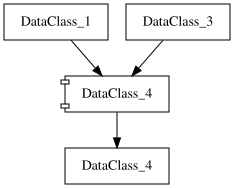

In [19]:

g = ProcessGraph()
g.add_process(Process_2)

# Display
dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)
display(SVG(dot_graph.pipe(format='svg')))

In [21]:
Process_1_plus_2.__name__

'Process_1_plus_2'